In [1]:
# Open training, testing subsets from https://doi.org/10.1021/acs.energyfuels.0c01533
from csv import DictReader

with open('schweidtmann_train.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_train = [r for r in reader]
csv_file.close()
with open('schweidtmann_test.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    compounds_test = [r for r in reader]
csv_file.close()

print(len(compounds_train), len(compounds_test))

# Filter out compounds with `n.a.` RON or MON data
compounds_train = [c for c in compounds_train if c['Meas DCN'] != 'n.a.']
compounds_test = [c for c in compounds_test if c['Meas DCN'] != 'n.a.']

print(len(compounds_train), len(compounds_test))

430 75
204 32


In [2]:
# Format data for training
from ecnet.datasets.structs import QSPRDataset

smiles_train = [c[' SMILES'] for c in compounds_train]
targets_train = [[float(c['Meas DCN'])] for c in compounds_train]

smiles_test = [c[' SMILES'] for c in compounds_test]
targets_test = [[float(c['Meas DCN'])] for c in compounds_test]

dataset_train = QSPRDataset(smiles_train, targets_train, backend='alvadesc')
dataset_test = QSPRDataset(smiles_test, targets_test, backend='alvadesc')

In [3]:
# Select most-influential descriptors w.r.t. RON and MON for NN input variables
from ecnet.tasks.feature_selection import select_rfr

print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
# Retain descriptors such that 99% of descriptor-property correlation is retained
desc_idx, desc_imp = select_rfr(dataset_train, total_importance=0.99, n_estimators=256, n_jobs=8)
dataset_train.set_desc_index(desc_idx)
dataset_test.set_desc_index(desc_idx)
print(dataset_train.desc_vals.shape, dataset_test.desc_vals.shape)
print(dataset_train.desc_names[:5], desc_imp[:5])

torch.Size([204, 5305]) torch.Size([32, 5305])
torch.Size([204, 839]) torch.Size([32, 839])
['SpMaxA_EA(ed)', 'SpMaxA_EA(bo)', 'PHI', 'X5Av', 'SssCH2'] [0.24273533768937763, 0.04754653963593042, 0.04359890041477438, 0.03425879273743187, 0.02747089855464849]


Epoch: 0 | Train loss: 886.8546266146233 | Valid loss: 9223372036854775807
Epoch: 10 | Train loss: 249.02174695722897 | Valid loss: 311.291259765625
Epoch: 20 | Train loss: 144.98967448041483 | Valid loss: 198.12843322753906
Epoch: 30 | Train loss: 139.12630983364363 | Valid loss: 172.74456787109375
Epoch: 40 | Train loss: 123.68308487406537 | Valid loss: 157.58718872070312
Epoch: 50 | Train loss: 68.83039035680103 | Valid loss: 100.80233001708984
Epoch: 60 | Train loss: 49.5711207945654 | Valid loss: 61.35710525512695
Epoch: 70 | Train loss: 57.5777628494918 | Valid loss: 58.60493469238281
Epoch: 80 | Train loss: 75.42185791577299 | Valid loss: 66.55704498291016
Epoch: 90 | Train loss: 58.79155149635362 | Valid loss: 41.09029006958008
Epoch: 100 | Train loss: 83.10038930506794 | Valid loss: 112.28749084472656
Epoch: 110 | Train loss: 38.02068135782253 | Valid loss: 30.760250091552734
Epoch: 120 | Train loss: 64.67156508510098 | Valid loss: 100.17472076416016
Epoch: 130 | Train loss: 2

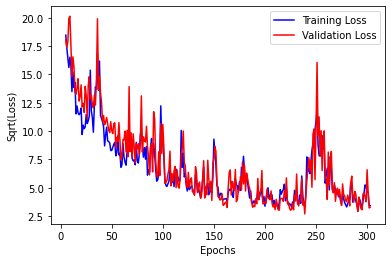

In [4]:
# Create ECNet model
from ecnet import ECNet
from math import sqrt
from matplotlib import pyplot as plt

model = ECNet(dataset_train.desc_vals.shape[1], dataset_train.target_vals.shape[1], 1024, 2, 0.001)
train_loss, valid_loss = model.fit(
    dataset=dataset_train, valid_size=0.2, shuffle=True, verbose=10,
    patience=64, epochs=1000, lr=0.001, lr_decay=0.0
)

# Plot sqrt(MSE loss)
train_loss = [sqrt(l) for l in train_loss][5:]
valid_loss = [sqrt(l) for l in valid_loss][5:]
epoch = [i for i in range(5, len(train_loss) + 5)]
plt.clf()
plt.xlabel('Epochs')
plt.ylabel('Sqrt(Loss)')
plt.plot(epoch, train_loss, color='blue', label='Training Loss')
plt.plot(epoch, valid_loss, color='red', label='Validation Loss')
plt.legend(loc='upper right')
plt.show()

In [6]:
from sklearn.metrics import mean_absolute_error, r2_score

y_hat_train = model(dataset_train.desc_vals).detach().numpy()
y_train = dataset_train.target_vals
train_mae = mean_absolute_error(y_hat_train, y_train)
train_r2 = r2_score(y_hat_train, y_train)
y_hat_test = model(dataset_test.desc_vals).detach().numpy()
y_test = dataset_test.target_vals
test_mae = mean_absolute_error(y_hat_test, y_test)
test_r2 = r2_score(y_hat_test, y_test)
print('Training median absolute error: {}'.format(train_mae))
print('Training r-squared coefficient: {}'.format(train_r2))
print('Testing median absolute error: {}'.format(test_mae))
print('Testing r-squared coefficient: {}'.format(test_r2))

Training median absolute error: 2.3468735218048096
Training r-squared coefficient: 0.9827213346292727
Testing median absolute error: 4.674679756164551
Testing r-squared coefficient: 0.9439459722624971


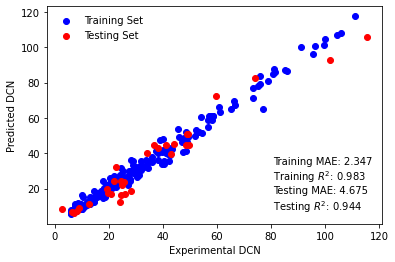

In [8]:
from matplotlib.offsetbox import AnchoredText

plt.clf()
plt.xlabel('Experimental DCN')
plt.ylabel('Predicted DCN')
plt.scatter(y_train, y_hat_train, color='blue', label='Training Set')
plt.scatter(y_test, y_hat_test, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(train_mae) + '\n'
string += 'Training $R^2$: {:.3f}'.format(train_r2) + '\n'
string += 'Testing MAE: {:.3f}'.format(test_mae) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(test_r2)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()

In [13]:
import numpy as np

train_results, test_results = [], []

# Similar to https://doi.org/10.1021/acs.energyfuels.0c01533, perform ensemble w/ 40 NNs
for i in range(40):

    print(f'Iteration {i}')

    model = ECNet(dataset_train.desc_vals.shape[1], dataset_train.target_vals.shape[1], 1024, 2, 0.001)
    _, _ = model.fit(
        dataset=dataset_train, valid_size=0.2, shuffle=True, verbose=0,
        patience=64, epochs=1000, lr=0.001, lr_decay=0.0
    )
    train_results.append(model(dataset_train.desc_vals).detach().numpy())
    test_results.append(model(dataset_test.desc_vals).detach().numpy())


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
Iteration 8
Iteration 9
Iteration 10
Iteration 11
Iteration 12
Iteration 13
Iteration 14
Iteration 15
Iteration 16
Iteration 17
Iteration 18
Iteration 19
Iteration 20
Iteration 21
Iteration 22
Iteration 23
Iteration 24
Iteration 25
Iteration 26
Iteration 27
Iteration 28
Iteration 29
Iteration 30
Iteration 31
Iteration 32
Iteration 33
Iteration 34
Iteration 35
Iteration 36
Iteration 37
Iteration 38
Iteration 39


In [14]:
train_res_mean = np.mean(train_results, axis=0)
test_res_mean = np.mean(test_results, axis=0)

In [16]:
train_mae = mean_absolute_error(train_res_mean, y_train)
train_r2 = r2_score(train_res_mean, y_train)
test_mae = mean_absolute_error(test_res_mean, y_test)
test_r2 = r2_score(test_res_mean, y_test)
print('Training median absolute error: {}'.format(train_mae))
print('Training r-squared coefficient: {}'.format(train_r2))
print('Testing median absolute error: {}'.format(test_mae))
print('Testing r-squared coefficient: {}'.format(test_r2))

Training median absolute error: 2.130805492401123
Training r-squared coefficient: 0.9832763295616144
Testing median absolute error: 4.868947982788086
Testing r-squared coefficient: 0.9295769337884059


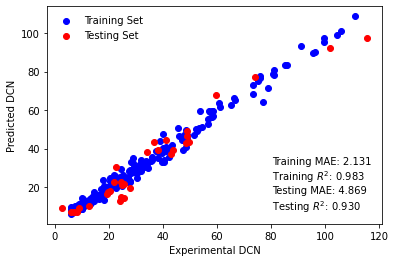

In [17]:
plt.clf()
plt.xlabel('Experimental DCN')
plt.ylabel('Predicted DCN')
plt.scatter(y_train, train_res_mean, color='blue', label='Training Set')
plt.scatter(y_test, test_res_mean, color='red', label='Testing Set')
plt.legend(loc='upper left', edgecolor='w')
string = 'Training MAE: {:.3f}'.format(train_mae) + '\n'
string += 'Training $R^2$: {:.3f}'.format(train_r2) + '\n'
string += 'Testing MAE: {:.3f}'.format(test_mae) + '\n'
string += 'Testing $R^2$: {:.3f}'.format(test_r2)
text_box = AnchoredText(string, frameon=True, loc=4, pad=0.5)
plt.setp(text_box.patch, facecolor='white', edgecolor='w')
plt.gca().add_artist(text_box)
plt.show()